In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("处理后数据集.xlsx", sheet_name="Sheet1")

# 编码类别标签
le = LabelEncoder()
df['pollutant_code'] = le.fit_transform(df['pollutant'])  # 用于分层的类别

# 分离特征和目标
X = df.drop(columns=['pollutant', 'kobs', 'pollutant_code']).values  # 输入特征
y = df['kobs'].values                # 回归目标
category_labels = df['pollutant_code'].values  # 分层依据的类别标签

In [7]:
# 初始化参数
n_splits = 5  # 折数
scoring = {
    'rmse': [],
    'mse': [],
    'r2': []
}

# 创建分层交叉验证器
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 循环每折
for fold, (train_idx, test_idx) in enumerate(skf.split(X, category_labels)):
    # 划分数据
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 标准化（防止数据泄露，仅在训练集上拟合）
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 初始化模型（每折重新创建）
    model = AutoTabPFNRegressor(max_time=240, device='cuda')

    # 训练
    model.fit(X_train_scaled, y_train)

    # 预测
    y_pred = model.predict(X_test_scaled)

    # 计算指标
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # 记录结果
    scoring['rmse'].append(rmse)
    scoring['mse'].append(mse)
    scoring['r2'].append(r2)

    # 打印当前折结果
    print(f"Fold {fold+1}: RMSE={rmse:.3f}, R²={r2:.3f}")

C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
2025-05-06 20:58:23 INFO     Using `default` preset for Post Hoc Ensemble.
2025-05-06 20:58:23 INFO     No categorical_feature_indices given. Assuming no categorical features.
2025-05-06 20:58:23 INFO     Using task type: regression
2025-05-06 20:58:23 INFO     Obtaining TabPFN models from a random portfolio.
2025-05-06 20:58:32 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_tabpfn_model_2', 'random_tabpfn_model_3', 'random_tabpfn_model_4', 'random_tabpfn_model_5', 'random_tabpfn_model_6', 'random_tabpfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_tabpfn_model_10', 'random_tabpfn_model_11', 'random_tabpfn_model_12', 'random_tabpfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_tabpfn_model_16

Fold 1: RMSE=0.140, R²=0.437


2025-05-06 21:02:39 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_tabpfn_model_2', 'random_tabpfn_model_3', 'random_tabpfn_model_4', 'random_tabpfn_model_5', 'random_tabpfn_model_6', 'random_tabpfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_tabpfn_model_10', 'random_tabpfn_model_11', 'random_tabpfn_model_12', 'random_tabpfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_tabpfn_model_16', 'random_tabpfn_model_17', 'random_tabpfn_model_18', 'random_tabpfn_model_19', 'random_tabpfn_model_20', 'random_tabpfn_model_21', 'random_tabpfn_model_22', 'random_tabpfn_model_23', 'random_tabpfn_model_24', 'random_tabpfn_model_25', 'random_tabpfn_model_26', 'random_tabpfn_model_27', 'random_tabpfn_model_28', 'random_tabpfn_model_29', 'random_tabpfn_model_30', 'random_tabpfn_model_31', 'random_tabpfn_model_32', 'random_tabpfn_model_33', 'random_tabpfn_model_34', 'random_tabpfn_model_35', 'random_tabpfn_model

Fold 2: RMSE=0.118, R²=0.525


2025-05-06 21:06:39 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_tabpfn_model_2', 'random_tabpfn_model_3', 'random_tabpfn_model_4', 'random_tabpfn_model_5', 'random_tabpfn_model_6', 'random_tabpfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_tabpfn_model_10', 'random_tabpfn_model_11', 'random_tabpfn_model_12', 'random_tabpfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_tabpfn_model_16', 'random_tabpfn_model_17', 'random_tabpfn_model_18', 'random_tabpfn_model_19', 'random_tabpfn_model_20', 'random_tabpfn_model_21', 'random_tabpfn_model_22', 'random_tabpfn_model_23', 'random_tabpfn_model_24', 'random_tabpfn_model_25', 'random_tabpfn_model_26', 'random_tabpfn_model_27', 'random_tabpfn_model_28', 'random_tabpfn_model_29', 'random_tabpfn_model_30', 'random_tabpfn_model_31', 'random_tabpfn_model_32', 'random_tabpfn_model_33', 'random_tabpfn_model_34', 'random_tabpfn_model_35', 'random_tabpfn_model

Fold 3: RMSE=0.108, R²=0.774


2025-05-06 21:10:41 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_tabpfn_model_2', 'random_tabpfn_model_3', 'random_tabpfn_model_4', 'random_tabpfn_model_5', 'random_tabpfn_model_6', 'random_tabpfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_tabpfn_model_10', 'random_tabpfn_model_11', 'random_tabpfn_model_12', 'random_tabpfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_tabpfn_model_16', 'random_tabpfn_model_17', 'random_tabpfn_model_18', 'random_tabpfn_model_19', 'random_tabpfn_model_20', 'random_tabpfn_model_21', 'random_tabpfn_model_22', 'random_tabpfn_model_23', 'random_tabpfn_model_24', 'random_tabpfn_model_25', 'random_tabpfn_model_26', 'random_tabpfn_model_27', 'random_tabpfn_model_28', 'random_tabpfn_model_29', 'random_tabpfn_model_30', 'random_tabpfn_model_31', 'random_tabpfn_model_32', 'random_tabpfn_model_33', 'random_tabpfn_model_34', 'random_tabpfn_model_35', 'random_tabpfn_model

Fold 4: RMSE=0.080, R²=0.878


2025-05-06 21:14:53 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_tabpfn_model_2', 'random_tabpfn_model_3', 'random_tabpfn_model_4', 'random_tabpfn_model_5', 'random_tabpfn_model_6', 'random_tabpfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_tabpfn_model_10', 'random_tabpfn_model_11', 'random_tabpfn_model_12', 'random_tabpfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_tabpfn_model_16', 'random_tabpfn_model_17', 'random_tabpfn_model_18', 'random_tabpfn_model_19', 'random_tabpfn_model_20', 'random_tabpfn_model_21', 'random_tabpfn_model_22', 'random_tabpfn_model_23', 'random_tabpfn_model_24', 'random_tabpfn_model_25', 'random_tabpfn_model_26', 'random_tabpfn_model_27', 'random_tabpfn_model_28', 'random_tabpfn_model_29', 'random_tabpfn_model_30', 'random_tabpfn_model_31', 'random_tabpfn_model_32', 'random_tabpfn_model_33', 'random_tabpfn_model_34', 'random_tabpfn_model_35', 'random_tabpfn_model

Fold 5: RMSE=0.091, R²=0.298



【交叉验证结果】(5折)
平均 RMSE : 0.107 ± 0.021
平均 R²   : 0.582


C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25240 (\N{CJK UNIFIED IDEOGRAPH-6298}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{

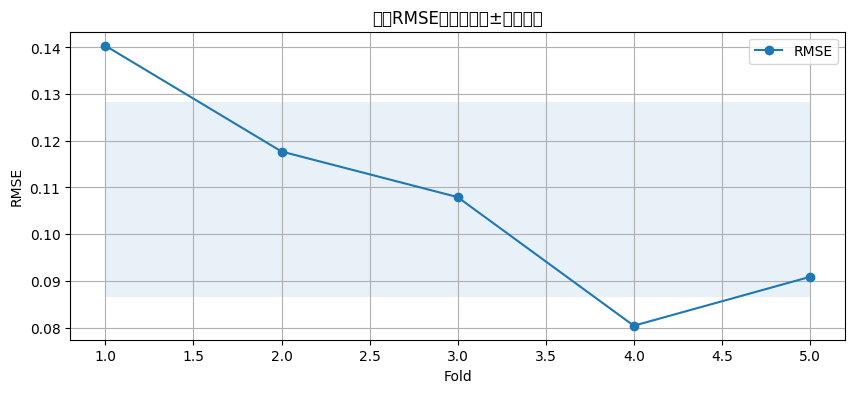

In [8]:
# 统计最终结果
final_rmse = np.mean(scoring['rmse'])
final_rmse_std = np.std(scoring['rmse'])
final_r2 = np.mean(scoring['r2'])

print("\n" + "="*50)
print(f"【交叉验证结果】({n_splits}折)")
print(f"平均 RMSE : {final_rmse:.3f} ± {final_rmse_std:.3f}")
print(f"平均 R²   : {final_r2:.3f}")
print("="*50)

# 可视化折间波动
plt.figure(figsize=(10,4))
plt.plot(range(1, n_splits+1), scoring['rmse'], 'o-', label='RMSE')
plt.fill_between(range(1, n_splits+1),
                 [final_rmse - final_rmse_std]*n_splits,
                 [final_rmse + final_rmse_std]*n_splits,
                 alpha=0.1)
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("各折RMSE波动（均值±标准差）")
plt.grid(True)
plt.legend()
plt.show()